In [1]:
from sklearn.datasets import load_iris
from sklearn.ensemble import IsolationForest
import pandas as pd

In [2]:
df=pd.read_csv('thyroid_dataset.csv')
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [3]:
df.columns

Index(['Age', 'Sex', 'on_thyroxine', 'query_on_thyroxine',
       'on_antithyroid_medication', 'sick', 'pregnant', 'thyroid_surgery',
       'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH', 'T3_measured',
       'TT4_measured', 'T4U_measured', 'FTI_measured', 'Outlier_label'],
      dtype='object')

In [9]:
from sklearn.preprocessing import StandardScaler

X = df.drop("Outlier_label", axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [11]:
from sklearn.ensemble import IsolationForest

# Features

# Create model
model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

In [12]:
labels=model.fit_predict(X)


In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca)

[[-2.8000256  -1.16360323]
 [-1.35756992 -0.95905031]
 [ 0.61449785 -2.64295808]
 ...
 [ 0.97067278 -0.03570015]
 [-0.48569635  1.00559244]
 [-0.31617833 -0.17796139]]


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

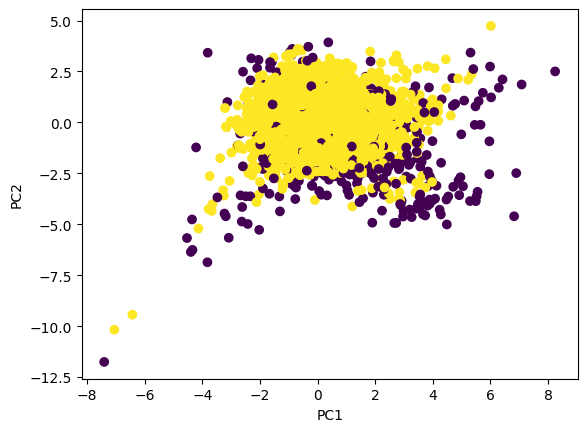

In [20]:
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()